# Taller — Construye y ajusta tu propio clasificador de imágenes

Este taller comienza **después de la teoría de CNN y del notebook guiado de transfer learning**.

La meta no es memorizar la API de Keras. La meta es tomar decisiones sobre un problema real: construir datos propios, adaptar un modelo preentrenado y analizar qué tan bien funciona.

---

## Organización de la actividad

| Momento | Tiempo estimado | Meta |
|---|---:|---|
| **Teoría + notebook guiado** | Se realiza antes de este taller | Comprender CNN, transfer learning y fine-tuning |
| **Trabajo en clase** | ~60 min | Construir el dataset y entrenar el primer modelo con la base congelada |
| **Trabajo en casa** | ~1–2 h | Evaluar, hacer fine-tuning, comparar y analizar errores |

### Regla importante

Durante el trabajo en clase usaremos **train** y **validation**.  
El conjunto de **test** se reservará para el trabajo en casa, cuando hagamos la evaluación final.

---

## Entrega final

Debes entregar **este mismo notebook ejecutado**, incluyendo:

- definición del problema y estrategia de búsqueda;
- dataset propio;
- primer entrenamiento con transfer learning;
- evaluación en test;
- fine-tuning;
- comparación antes/después;
- matriz de confusión;
- análisis de al menos 5 errores;
- conclusiones.

## 0. Preparación del entorno

La búsqueda de imágenes se realizará con `ddgs`. Si estás en Google Colab, ejecuta la siguiente celda.

In [1]:
!pip -q install -U ddgs

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
import hashlib, io, random, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image

import tensorflow as tf
import keras
from keras import layers
from ddgs import DDGS
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Keras: 3.15.1
TensorFlow: 2.21.0


GPU: []


# PARTE A — TRABAJO EN CLASE (~60 min)

## Objetivo de esta parte

Antes de terminar la sesión debes haber conseguido:

1. definir un problema de clasificación de 3 clases;
2. descargar y revisar un dataset propio;
3. separar los datos en `train`, `validation` y `test`;
4. cargar EfficientNetB0 preentrenada en ImageNet;
5. congelar el backbone;
6. entrenar una nueva cabeza de clasificación;
7. observar `accuracy` y `val_accuracy`.

> **No evalúes todavía sobre `test`.** Ese conjunto queda reservado para el trabajo en casa.

### Distribución sugerida

- **10 min** — problema y términos de búsqueda;
- **20 min** — descarga, inspección y limpieza;
- **10 min** — separación y carga del dataset;
- **20 min** — transfer learning y primer entrenamiento.

# 1. Define tu problema — EN CLASE

Elige un problema de clasificación de **3 clases**. Las clases deben ser visualmente distinguibles.

Ejemplos: `espresso/cappuccino/latte`, `bus/motorcycle/bicycle`, tres especies de flores, frutas, tipos de calzado o instrumentos musicales.

Evita problemas donde la clase dependa de información que no aparece visualmente en la imagen.

## TODO 1 — Problema y estrategia de búsqueda

Define:

1. las tres clases;
2. dos o tres términos de búsqueda por clase;
3. una breve hipótesis: **¿qué características visuales esperas que use el modelo?**;
4. un posible sesgo o fuente de *data leakage* que podría aparecer al descargar imágenes desde un buscador.

In [3]:
# TODO 1 — EN CLASE: define tus clases y búsquedas
SEARCHES = {
    "bicicleta": [
        "bicycle parked on street photo",
        "mountain bike photo",
        "road bike side view",
    ],
    "bus": [
        "city bus on street photo",
        "public transit bus",
        "double decker bus photo",
    ],
    "moto": [
        "motorcycle parked photo",
        "sport motorcycle side view",
        "motorbike on road",
    ],
}

SEARCHES

{'bicicleta': ['bicycle parked on street photo',
  'mountain bike photo',
  'road bike side view'],
 'bus': ['city bus on street photo',
  'public transit bus',
  'double decker bus photo'],
 'moto': ['motorcycle parked photo',
  'sport motorcycle side view',
  'motorbike on road']}

**Problema:** clasificar fotos de vehículos en tres clases: bicicleta, bus y moto. Usé tres búsquedas en inglés por clase porque en inglés el buscador trae más fotos.

**Hipótesis:** espero que el modelo use el tamaño y la forma general. El bus es un rectángulo grande con muchas ventanas; la bicicleta tiene un marco delgado, ruedas con rayos y pedales; la moto tiene ruedas más gruesas, motor, tanque y en general se ve más pesada.

**Posible sesgo o leakage:** las fotos de bancos de imágenes traen marcas de agua y el fondo puede delatar la clase (las bicicletas en parqueaderos de ciudad, las motos en carreteras, los buses en calles con tráfico). Además buscadores distintos pueden devolver la misma foto o casi la misma, y si una queda en train y la otra en test se infla la accuracy.

### Antes de descargar

Escribe debajo de esta celda una respuesta corta:

- ¿Qué características visuales esperas que diferencien tus clases?
- ¿Qué imágenes incorrectas esperas encontrar?
- ¿Qué sesgo o *data leakage* podría aparecer?

**Respuesta:**

Espero que las clases se diferencien por la forma y el tamaño: el bus es mucho más grande, cuadrado y con ventanas; la bicicleta es delgada, sin motor y con pedales; la moto tiene motor, tanque, ruedas gruesas y luces grandes.

Imágenes incorrectas que espero encontrar: dibujos o iconos, juguetes y miniaturas, piezas sueltas (llantas, cascos, motores), interiores de buses, tranvías en vez de buses, scooters o patinetas en la clase moto, y fotos donde aparecen dos clases a la vez.

Sesgo o leakage: los fondos pueden estar correlacionados con la clase (motos en carretera, buses en avenidas), las marcas de agua de los bancos de fotos, un color dominante si una búsqueda trae siempre el mismo modelo de bus, y duplicados casi iguales que caigan uno en train y otro en test.

# 2. Buscar y descargar imágenes — EN CLASE

La siguiente función busca imágenes y descarga los resultados. Intenta ignorar URLs fallidas, verificar las imágenes, evitar duplicados exactos con un hash y convertirlas a RGB.

> Se solicita contenido con licencia Creative Commons cuando el motor lo soporta. Eso no sustituye la revisión de licencias si el dataset se va a redistribuir.

In [4]:
RAW_DIR = Path("data_raw")
RAW_DIR.mkdir(exist_ok=True)

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def download_image_dataset(searches, root=RAW_DIR, images_per_query=60, min_side=120, timeout=8):
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})

    # Incluye imágenes de ejecuciones anteriores para que volver a ejecutar
    # la descarga no agregue duplicados exactos al dataset.
    seen_hashes = {
        file_sha256(path)
        for path in Path(root).glob("*/*.jpg")
        if path.is_file()
    }

    for class_name, queries in searches.items():
        class_dir = root / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        saved = len(list(class_dir.glob("*.jpg")))
        print(f"\n=== {class_name} ===")

        for query in queries:
            print(f"Buscando: {query!r}")
            try:
                results = DDGS().images(
                    query=query,
                    safesearch="moderate",
                    max_results=images_per_query,
                    license_image="any",
                )
            except Exception as e:
                print("  Error en búsqueda:", e)
                continue

            for result in results:
                url = result.get("image")
                if not url:
                    continue
                try:
                    response = session.get(url, timeout=timeout)
                    response.raise_for_status()
                    data = response.content
                    digest = hashlib.sha256(data).hexdigest()
                    if digest in seen_hashes:
                        continue

                    with Image.open(io.BytesIO(data)) as img:
                        img = img.convert("RGB")
                        if min(img.size) < min_side:
                            continue
                        filename = class_dir / f"{saved:04d}.jpg"
                        img.save(filename, format="JPEG", quality=90)

                    seen_hashes.add(digest)
                    saved += 1
                except Exception:
                    pass

            print(f"  Total guardadas hasta ahora: {saved}")
            time.sleep(1)

    print("\nDescarga terminada.")

## TODO 2 — EN CLASE: construye y limpia tu dataset

Tu objetivo inicial es obtener aproximadamente **100–150 imágenes útiles por clase**.

1. Ejecuta la descarga.
2. Inspecciona muestras aleatorias.
3. Mejora los términos de búsqueda si una clase trae resultados pobres.
4. Elimina imágenes claramente incorrectas o problemáticas.
5. Reporta el número final de imágenes por clase y describe el error más frecuente que encontraste.

> Si la búsqueda trae datos malos, **no aumentes simplemente `max_results`**. Primero mejora los términos de búsqueda.

In [5]:
# TODO 2 — EN CLASE: ejecuta la descarga con tus búsquedas
download_image_dataset(
    SEARCHES,
    images_per_query=60,
)


=== bicicleta ===
Buscando: 'bicycle parked on street photo'


  Total guardadas hasta ahora: 31


Buscando: 'mountain bike photo'


  Total guardadas hasta ahora: 60


Buscando: 'road bike side view'


...

Buscando: 'sport motorcycle side view'


  Total guardadas hasta ahora: 65


Buscando: 'motorbike on road'


  Total guardadas hasta ahora: 98



Descarga terminada.


In [6]:
def count_images(root):
    counts = {}
    for folder in sorted(Path(root).iterdir()):
        if folder.is_dir():
            counts[folder.name] = len(list(folder.glob("*.jpg")))
    return counts

count_images(RAW_DIR)

{'bicicleta': 91, 'bus': 92, 'moto': 98}

## Validación técnica automática de las imágenes

Antes de inspeccionar el contenido del dataset, comprobaremos que **TensorFlow pueda decodificar todas las imágenes**.

Esto resuelve un problema distinto al de la inspección visual:

- **Validación técnica:** ¿el archivo puede ser leído correctamente por TensorFlow?
- **Validación semántica:** ¿la imagen realmente pertenece a la clase indicada?

Una imagen puede abrirse aparentemente bien en otras librerías y aun así fallar durante `model.fit()`. Por eso hacemos esta comprobación usando el mismo decoder que utilizará el pipeline de Keras.

In [7]:
def remove_invalid_images(root_dir):
    root_dir = Path(root_dir)
    bad_files = []

    for path in root_dir.rglob("*.jpg"):
        try:
            raw = tf.io.read_file(str(path))

            img = tf.io.decode_image(
                raw,
                channels=3,
                expand_animations=False,
            )

            # Forzamos la ejecución para detectar errores de decodificación.
            _ = img.numpy()

        except Exception as e:
            print("Imagen inválida:", path)
            print(" ", str(e).splitlines()[0])
            bad_files.append(path)

    for path in bad_files:
        path.unlink(missing_ok=True)

    print(f"\nImágenes inválidas eliminadas: {len(bad_files)}")

    return bad_files


bad_files = remove_invalid_images(RAW_DIR)


Imágenes inválidas eliminadas: 0


### Verificación

Ejecuta nuevamente la función. El resultado esperado es:

```text
Imágenes inválidas eliminadas: 0
```

Si todavía aparece alguna imagen inválida, vuelve a ejecutar hasta obtener cero antes de continuar.

In [8]:
bad_files = remove_invalid_images(RAW_DIR)

assert len(bad_files) == 0, (
    "Todavía quedan imágenes que TensorFlow no puede decodificar."
)

print("✓ Todas las imágenes pueden ser decodificadas por TensorFlow.")


Imágenes inválidas eliminadas: 0
✓ Todas las imágenes pueden ser decodificadas por TensorFlow.


# 3. Inspección y limpieza semántica — EN CLASE

La etapa anterior confirmó que los archivos son **técnicamente válidos**.

Ahora viene una tarea diferente: comprobar si los datos son **semánticamente correctos**.

Busca especialmente:

- imágenes que no correspondan a la clase;
- dibujos, logos o diagramas si tu objetivo son fotografías;
- imágenes con texto que pueda revelar artificialmente la etiqueta;
- duplicados o imágenes casi idénticas;
- fondos que estén correlacionados con una clase;
- diferencias sistemáticas de estilo o calidad entre clases.

> Que TensorFlow pueda abrir una imagen no significa que sea un buen dato de entrenamiento.

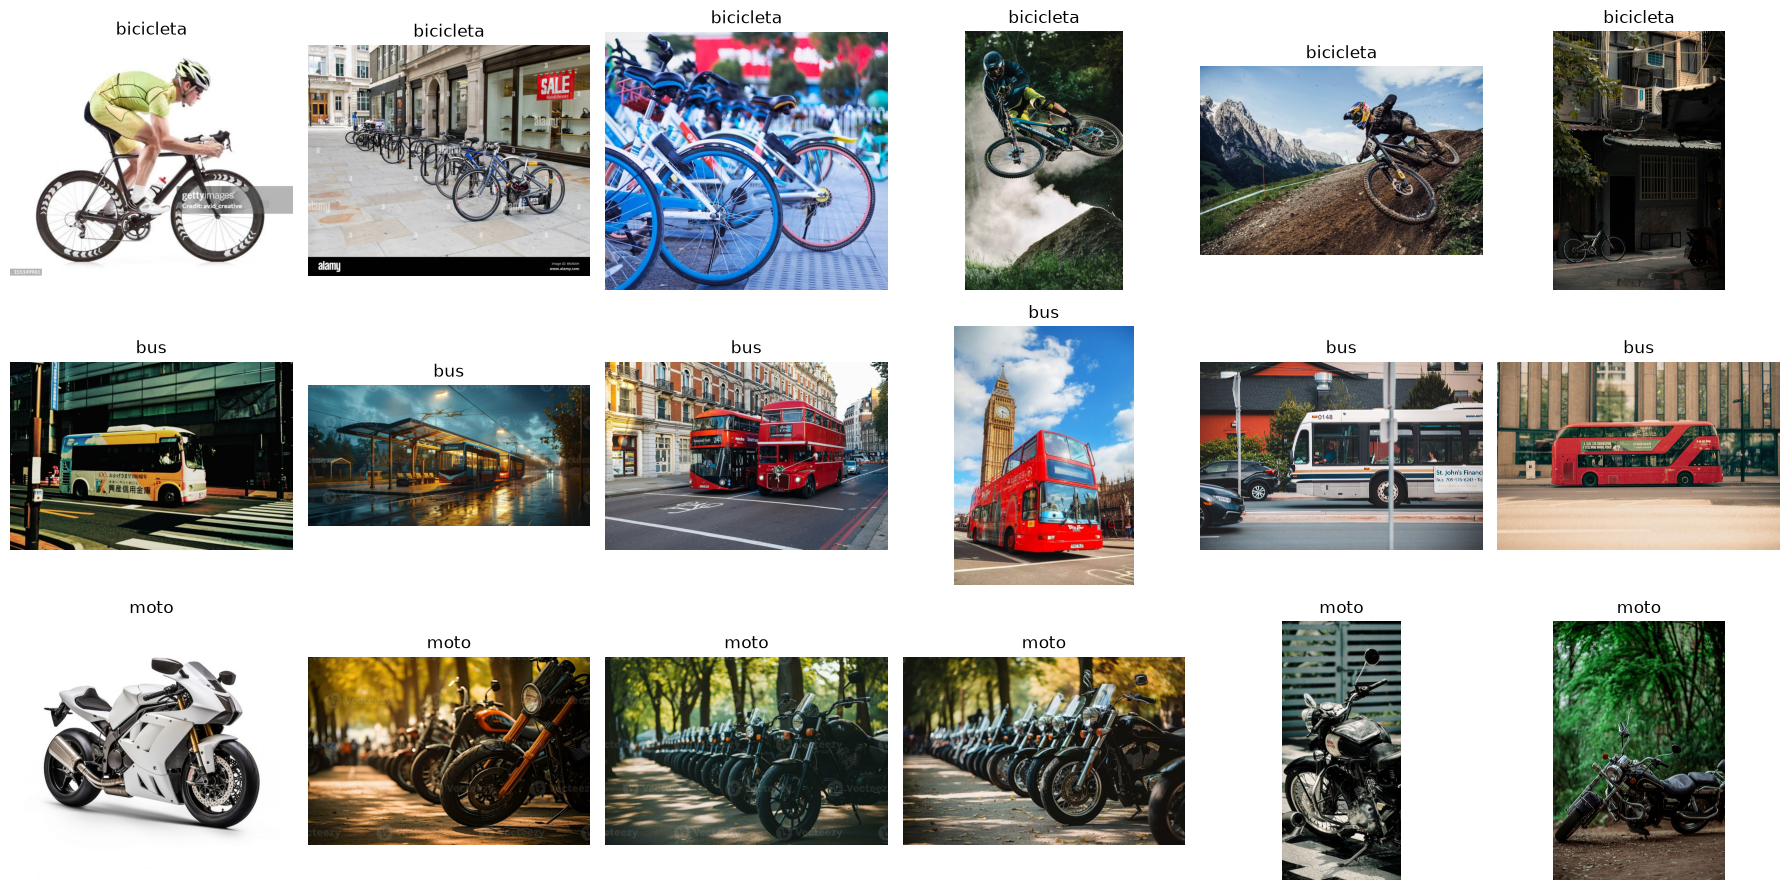

In [9]:
def show_random_images(root, n_per_class=6):
    root = Path(root)
    class_dirs = [p for p in sorted(root.iterdir()) if p.is_dir()]
    fig, axes = plt.subplots(len(class_dirs), n_per_class, figsize=(3*n_per_class, 3*len(class_dirs)))
    if len(class_dirs) == 1:
        axes = np.expand_dims(axes, 0)
    for row, class_dir in enumerate(class_dirs):
        files = list(class_dir.glob("*.jpg"))
        chosen = random.sample(files, min(n_per_class, len(files)))
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img = Image.open(chosen[col])
                ax.imshow(img)
                ax.set_title(class_dir.name)
            ax.axis("off")
    plt.tight_layout()

show_random_images(RAW_DIR)

In [10]:
# Revise todas las imagenes de cada carpeta y anote las que no corresponden
borrar = {
    "bicicleta": [
        "0030",  # bicitaxi con pasajero, no es una bicicleta normal
        "0076",  # dibujo de una bicicleta
        "0080",  # ciclista de cerca, la bicicleta casi no se ve
        "0086",  # foto de cerca del faro de una moto
    ],
    "bus": [
        "0013",  # render de una estacion, no se distingue el bus
        "0040",  # interior del bus con pasajeros
        "0042",  # ilustracion futurista
        "0043",  # render/ilustracion de una terminal
        "0044",  # interior del bus, solo sillas
        "0047",  # render de un bus futurista
        "0050",  # infografia
        "0054",  # dibujo de buses
        "0055",  # render tipo juguete sobre una hoja
        "0056",  # pedazo de la puerta de un bus con letrero
        "0057",  # poster ilustrado con texto
        "0058",  # tranvia, no es bus
        "0060",  # tranvia, no es bus
        "0085",  # dibujo vectorial de un bus de Londres
    ],
    "moto": [
        "0028",  # moto y bicicleta juntas en la misma foto
        "0035",  # collage de 4 motos
        "0039",  # mockup con fondo de cuadros
        "0042",  # collage de 4 motos
        "0046",  # render de moto con rueditas de juguete
        "0049",  # dibujo de una moto de fantasia
        "0056",  # mockup con fondo de cuadros
        "0062",  # collage de 4 motos
        "0081",  # pintura de una moto
    ],
}

antes = count_images(RAW_DIR)
for clase, archivos in borrar.items():
    for nombre in archivos:
        (RAW_DIR / clase / f"{nombre}.jpg").unlink(missing_ok=True)

despues = count_images(RAW_DIR)
for clase in antes:
    print(f"{clase:10s} antes: {antes[clase]:3d}   borradas: {antes[clase] - despues[clase]:2d}   quedan: {despues[clase]}")
print("Total borradas:", sum(antes.values()) - sum(despues.values()))

bicicleta  antes:  91   borradas:  4   quedan: 87
bus        antes:  92   borradas: 14   quedan: 78
moto       antes:  98   borradas:  9   quedan: 89
Total borradas: 27


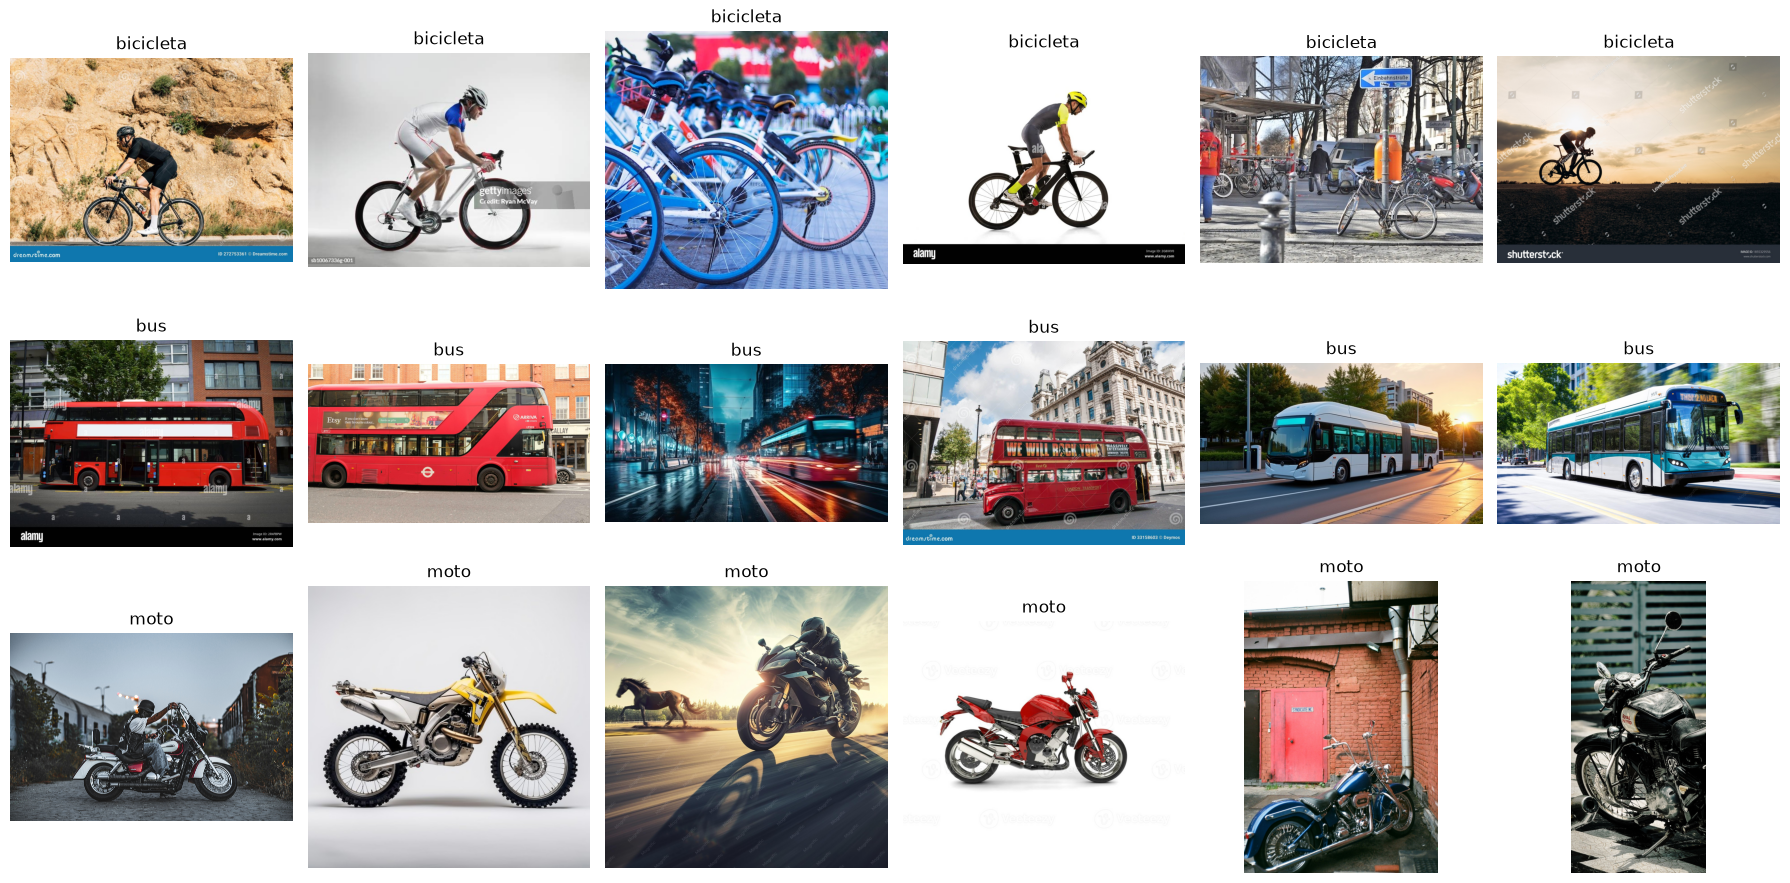

In [11]:
show_random_images(RAW_DIR)

### Checkpoint del dataset

Antes de continuar, asegúrate de que:

- cada carpeta contiene imágenes realmente asociadas a su clase;
- no predominan logos, dibujos o texto que revele la etiqueta;
- no hay una diferencia de fondo/estilo demasiado obvia entre clases;
- el número de imágenes por clase es razonablemente balanceado.

Registra aquí el número de imágenes eliminadas y el problema de calidad más frecuente.

**Registro:** revisé todas las imágenes de las tres carpetas (con hojas de contacto con el nombre de cada archivo) y borré 27 en total:

Bicicleta: descargué 91, borré 4 y quedaron 87.

Bus: descargué 92, borré 14 y quedaron 78.

Moto: descargué 98, borré 9 y quedaron 89.

El problema más frecuente fueron las imágenes que no son fotos reales: dibujos, infografías, renders y collages (sobre todo en bus). También borré interiores de buses, tranvías, un bicitaxi, un faro de moto que estaba en bicicletas y una foto que tenía una moto y una bicicleta juntas. No encontré juguetes como tal, pero sí una moto renderizada con rueditas de juguete. Lo que no borré pero noté es que muchas fotos tienen marca de agua (alamy, getty, shutterstock) y que en bus hay muchísimos buses rojos de dos pisos por la búsqueda "double decker", eso es un sesgo de color. Las clases quedaron más o menos balanceadas.

# 4. Separar train, validation y test — EN CLASE

> **Concepto clave — tres conjuntos, tres funciones**
>
> - **Train:** se utiliza para actualizar los pesos del modelo.
> - **Validation:** se utiliza durante el desarrollo para decidir épocas, `learning_rate`, número de capas a descongelar, etc.
> - **Test:** se reserva para medir el rendimiento final. No debe guiar las decisiones de entrenamiento.

Usaremos **70 % entrenamiento, 15 % validación y 15 % prueba**.

In [12]:
SPLIT_DIR = Path("dataset")

def split_dataset(source_root, destination_root, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    source_root = Path(source_root)
    destination_root = Path(destination_root)
    if destination_root.exists():
        shutil.rmtree(destination_root)
    rng = random.Random(seed)

    for class_dir in sorted(source_root.iterdir()):
        if not class_dir.is_dir():
            continue
        files = list(class_dir.glob("*.jpg"))
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            "train": files[:n_train],
            "validation": files[n_train:n_train+n_val],
            "test": files[n_train+n_val:],
        }
        for split_name, split_files in splits.items():
            target = destination_root / split_name / class_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, target / src.name)

split_dataset(RAW_DIR, SPLIT_DIR)
for split in ["train", "validation", "test"]:
    print(split, count_images(SPLIT_DIR / split))

train {'bicicleta': 60, 'bus': 54, 'moto': 62}
validation {'bicicleta': 13, 'bus': 11, 'moto': 13}
test {'bicicleta': 14, 'bus': 13, 'moto': 14}


### Comprobación conceptual

Explica brevemente: ¿por qué usar repetidamente el conjunto de prueba para escoger épocas, `learning_rate` o capas a descongelar termina contaminando nuestra estimación de desempeño?

**Respuesta:** porque cada vez que miro el resultado en test y cambio algo para que mejore, estoy escogiendo el modelo que mejor le va a esas imágenes en particular. Después de varias pruebas el test ya no es un dato nuevo, se volvió parte del ajuste igual que validation, y la accuracy que reporto sale optimista. Además con un test tan pequeño (41 imágenes) es fácil escoger algo que funciona por suerte en esas fotos. Por eso las decisiones se toman con validation y el test se usa una sola vez al final.

# 5. Construir los datasets de Keras — EN CLASE

`image_dataset_from_directory()` construye un `tf.data.Dataset` usando el nombre de las carpetas como clases.

Observa que:

- `train` se mezcla (`shuffle=True`);
- `validation` y `test` mantienen un orden estable;
- todas las imágenes se redimensionan a `224×224` para EfficientNetB0.

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
print(class_names)

Found 176 files belonging to 3 classes.


Found 37 files belonging to 3 classes.


Found 41 files belonging to 3 classes.


['bicicleta', 'bus', 'moto']


# 6. Primer modelo: transfer learning — EN CLASE

Usaremos **EfficientNetB0** preentrenada en ImageNet. Primero congelaremos completamente la red base y entrenaremos solo una nueva cabeza de clasificación.

> **Concepto clave — Data augmentation**
>
> `RandomFlip`, `RandomRotation` y `RandomZoom` generan variaciones plausibles durante el entrenamiento. No crean información nueva, pero ayudan a que el modelo dependa menos de detalles accidentales de las imágenes descargadas.

> **Concepto clave — GlobalAveragePooling2D**
>
> En lugar de aplanar todos los mapas de características con `Flatten`, `GlobalAveragePooling2D` resume cada canal en un solo valor. Así reducimos mucho el número de parámetros de la cabeza de clasificación.

In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## TODO 3 — EN CLASE: entrena la cabeza de clasificación

La base EfficientNet está congelada. Tu trabajo es configurar y entrenar la nueva cabeza.

> **Concepto clave — EarlyStopping**
>
> `EarlyStopping` detiene el entrenamiento cuando `val_loss` deja de mejorar. Con `restore_best_weights=True`, Keras recupera los pesos de la mejor época observada en validación.

Antes de ejecutar, escribe una predicción corta:

- ¿esperas que `train_accuracy` suba rápidamente?
- ¿qué señal en las curvas indicaría overfitting?

Completa únicamente los espacios `TODO` del código siguiente.

**Predicción antes de ejecutar:** espero que train_accuracy suba muy rápido desde la primera o segunda epoch, porque la base ya sabe reconocer bicicletas, buses y motos desde ImageNet y solo hay que entrenar la última capa. La señal de overfitting sería que train_accuracy siga subiendo hacia 1.0 mientras val_loss empieza a subir o val_accuracy se queda quieta o baja.

In [15]:
# TODO 3 — EN CLASE: completa la configuración de entrenamiento

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # 1e-3
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],                                      # "accuracy"
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",                  # "val_loss"
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10


C:\Users\Usuario\anaconda3\envs\ia\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.2188 - loss: 1.3095

2/6 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.2500 - loss: 1.2561

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.3125 - loss: 1.2350

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9792 - loss: 0.1262

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9766 - loss: 0.1238

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9812 - loss: 0.1176

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9830 - loss: 0.1233

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 274ms/step - accuracy: 0.9830 - loss: 0.1233 - val_accuracy: 0.9730 - val_loss: 0.1066


### Curvas de aprendizaje — EN CLASE si el tiempo lo permite

Grafica `accuracy`, `val_accuracy`, `loss` y `val_loss`.

Si el tiempo de clase termina antes, **puedes completar estas curvas en casa**.  
Lo obligatorio antes de salir es haber entrenado el primer modelo y tener sus métricas de entrenamiento/validación.

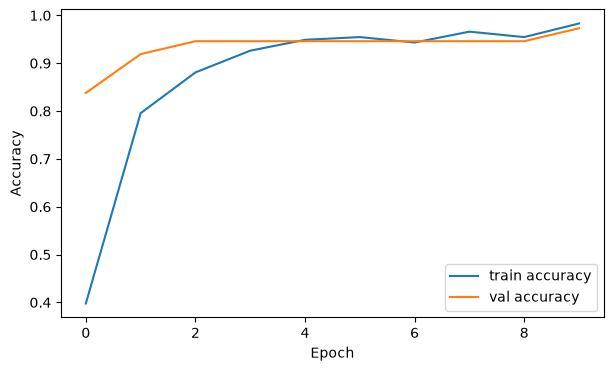

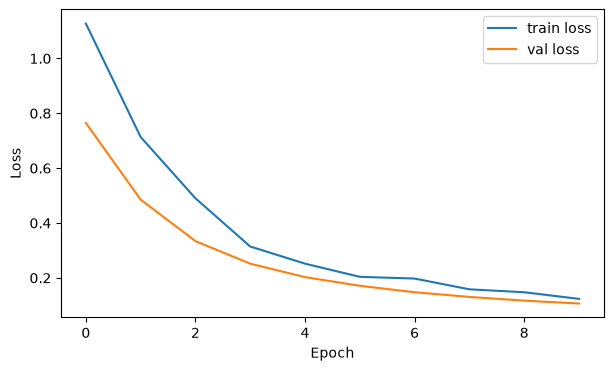

In [16]:
# Completa las cuatro curvas usando el objeto history
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Resultado del primer entrenamiento:** se cumplió lo que esperaba. En la primera epoch la train accuracy fue 0.40 y la val accuracy ya era 0.84; en la epoch 3 train iba en 0.88 y validation en 0.946. Al final (epoch 10) quedó train accuracy de 0.98 y val accuracy de 0.973, con val_loss de 0.1066. La val_loss bajó en todas las epochs, por eso el EarlyStopping no se activó. No hay overfitting: la val_loss nunca subió y la diferencia entre train y validation es muy pequeña.

# PUNTO DE CONTROL — FIN DEL TRABAJO EN CLASE

Antes de continuar, verifica que tu equipo tenga:

- [x] 3 clases definidas;
- [x] términos de búsqueda documentados;
- [x] imágenes descargadas;
- [x] dataset inspeccionado y parcialmente limpiado;
- [x] separación `train / validation / test`;
- [x] EfficientNetB0 con pesos de ImageNet;
- [x] backbone congelado;
- [x] nueva cabeza de clasificación;
- [x] al menos un entrenamiento completado;
- [x] `accuracy` y `val_accuracy` reportadas.

## Hasta aquí llega el trabajo de clase.

**No uses todavía el conjunto de test para tomar decisiones.**

---

# PARTE B — TRABAJO EN CASA

A partir de este punto debes completar el análisis de manera autónoma.

Ahora sí vas a:

1. evaluar el modelo en `test`;
2. estudiar la matriz de confusión y métricas por clase;
3. realizar fine-tuning;
4. comparar el modelo congelado contra el modelo ajustado;
5. analizar errores;
6. escribir las conclusiones.

# 7. Evaluación del primer modelo — EN CASA

Ahora sí utilizaremos el conjunto de prueba.

> **Concepto clave — No todo es accuracy**
>
> - **Precision:** de las imágenes que el modelo predijo como una clase, ¿cuántas eran correctas?
> - **Recall:** de las imágenes que realmente pertenecían a una clase, ¿cuántas encontró?
> - **F1:** combina precision y recall.
> - **Matriz de confusión:** muestra qué clases se están confundiendo entre sí.

Guarda esta evaluación: será nuestra línea base antes del fine-tuning.

In [17]:
test_loss_before, test_acc_before = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy antes del fine-tuning: {test_acc_before:.4f}")

Test accuracy antes del fine-tuning: 1.0000


              precision    recall  f1-score   support

   bicicleta      1.000     1.000     1.000        14
         bus      1.000     1.000     1.000        13
        moto      1.000     1.000     1.000        14

    accuracy                          1.000        41
   macro avg      1.000     1.000     1.000        41
weighted avg      1.000     1.000     1.000        41



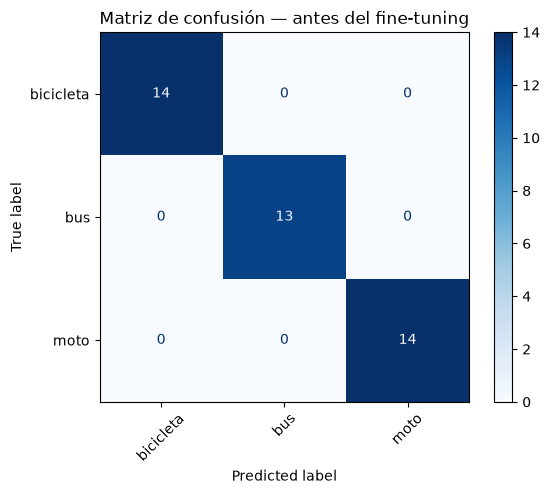

In [18]:
def get_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    probabilities = model.predict(dataset, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    return y_true, y_pred, probabilities

y_true, y_pred, probabilities = get_predictions(model, test_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — antes del fine-tuning")
plt.show()

## TODO 4 — EN CASA: interpreta la evaluación

Utilizando `classification_report` y la matriz de confusión, responde:

1. ¿Cuál clase obtuvo mejores resultados?
2. ¿Cuál fue la principal confusión?
3. ¿La accuracy global oculta algún problema por clase?
4. ¿Qué cambiarías primero en el **dataset** antes de cambiar el modelo?

**Respuesta:**

1. Las tres clases salieron perfectas en test: precision, recall y f1 de 1.000 para bicicleta, bus y moto. Si tengo que escoger una, bus es la más fácil porque es mucho más grande y tiene forma de caja, y en validation tampoco tuvo errores.
2. En test no hubo ninguna confusión, la matriz de confusión es diagonal. En validation el único error fue una moto de motocross que predijo como bicicleta, así que la confusión que hay que vigilar es moto con bicicleta, que son las que más se parecen (dos ruedas, manubrio).
3. En este caso no, porque todas las clases tienen 1.000. Pero el test es muy pequeño (14, 13 y 14 imágenes), entonces un 100 % no quiere decir que el modelo nunca se equivoque, solo que estas 41 fotos fueron fáciles.
4. Primero agregaría más variedad a la clase moto (motocross, scooters, motos vistas de frente) y quitaría las fotos con marca de agua. También buscaría buses de otros colores porque casi la mitad son rojos de dos pisos, y eso puede hacer que el modelo use el color rojo como atajo.

# 8. Fine-tuning — EN CASA

Ahora permitiremos que una pequeña parte de EfficientNet se adapte al nuevo problema.

> **Concepto clave — Fine-tuning**
>
> En la fase anterior, los pesos del backbone no cambiaron. Ahora descongelaremos únicamente una parte final del modelo y la actualizaremos con un **learning rate mucho menor**.

> **Concepto clave — Batch Normalization**
>
> EfficientNet contiene capas `BatchNormalization`, que mantienen estadísticas internas aprendidas durante el entrenamiento. En datasets pequeños conviene mantenerlas congeladas durante fine-tuning para evitar actualizaciones inestables de esas estadísticas.

Después de cambiar qué capas son entrenables, es necesario **recompilar** el modelo.

In [19]:
base_model.trainable = True

# TODO 5 — Decide cuántas capas finales adaptar.
# Empieza con ~20. Puedes justificar otro valor usando validation.
N_UNFROZEN = 20

for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

# Mantener Batch Normalization congelado.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Capas entrenables de la base:",
    sum(layer.trainable for layer in base_model.layers),
    "/",
    len(base_model.layers),
)

Capas entrenables de la base: 15 / 238


## TODO 5 — EN CASA: realiza fine-tuning

Recompila y continúa el entrenamiento.

Usa como punto de partida:

- `Adam(learning_rate=1e-5)`;
- `SparseCategoricalCrossentropy`;
- `accuracy`;
- entre **3 y 8 épocas** adicionales;
- `EarlyStopping` sobre `val_loss`.

Tu decisión principal aquí es **cuántas capas descongelar**. Justifícala usando el desempeño de validación, no el conjunto de prueba.

**Decisión:** usé N_UNFROZEN = 20 como sugiere el taller. Como las capas de BatchNormalization se dejan congeladas, en realidad quedaron 15 capas entrenables de 238. No probé más capas porque la validación ya estaba en 0.973 con la base congelada y con tan pocas imágenes (176 en train) descongelar mucho podría sobreajustar. En validation el resultado fue bueno: la val_loss siguió bajando en las 8 epochs (de 0.1013 a 0.0741) sin que el EarlyStopping tuviera que parar, y la val_accuracy se mantuvo en 0.973, entonces no hubo señales de overfitting.

In [20]:
# TODO 5 — EN CASA: completa el fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 1e-5
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,  # entre 3 y 8
    callbacks=[early_stopping_ft],
)

Epoch 1/8


C:\Users\Usuario\anaconda3\envs\ia\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step - accuracy: 1.0000 - loss: 0.1047

2/6 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9844 - loss: 0.1122

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9792 - loss: 0.1161

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9896 - loss: 0.0785

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9844 - loss: 0.0772

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9812 - loss: 0.0812

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9830 - loss: 0.0841

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.9830 - loss: 0.0841 - val_accuracy: 0.9730 - val_loss: 0.0741


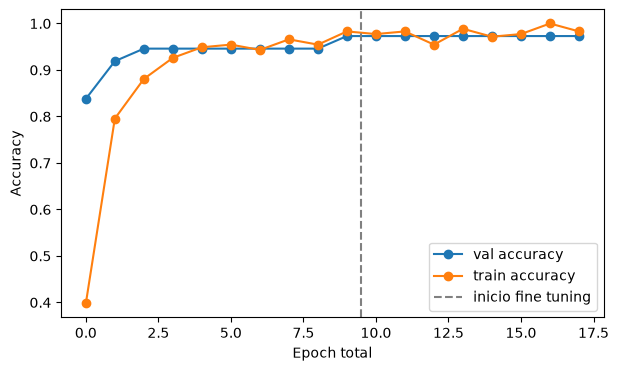

Mejor val_loss fase congelada: 0.1066
Mejor val_loss fine tuning   : 0.0741


In [21]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["val_accuracy"] + history_ft.history["val_accuracy"], marker="o", label="val accuracy")
plt.plot(history.history["accuracy"] + history_ft.history["accuracy"], marker="o", label="train accuracy")
plt.axvline(len(history.history["accuracy"]) - 0.5, color="gray", linestyle="--", label="inicio fine tuning")
plt.xlabel("Epoch total")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("Mejor val_loss fase congelada:", round(min(history.history["val_loss"]), 4))
print("Mejor val_loss fine tuning   :", round(min(history_ft.history["val_loss"]), 4))

# 9. Comparación final — EN CASA

Compara el desempeño del mismo sistema **antes y después** del fine-tuning.

Una mejora pequeña también puede ser válida. Si el resultado empeora, no significa que el experimento “salió mal”: debes interpretar por qué pudo ocurrir.

In [22]:
test_loss_after, test_acc_after = model.evaluate(test_ds, verbose=0)
print(f"Antes del fine-tuning  : {test_acc_before:.4f}")
print(f"Después del fine-tuning: {test_acc_after:.4f}")
print(f"Diferencia              : {test_acc_after-test_acc_before:+.4f}")

Antes del fine-tuning  : 1.0000
Después del fine-tuning: 1.0000
Diferencia              : +0.0000


              precision    recall  f1-score   support

   bicicleta      1.000     1.000     1.000        14
         bus      1.000     1.000     1.000        13
        moto      1.000     1.000     1.000        14

    accuracy                          1.000        41
   macro avg      1.000     1.000     1.000        41
weighted avg      1.000     1.000     1.000        41



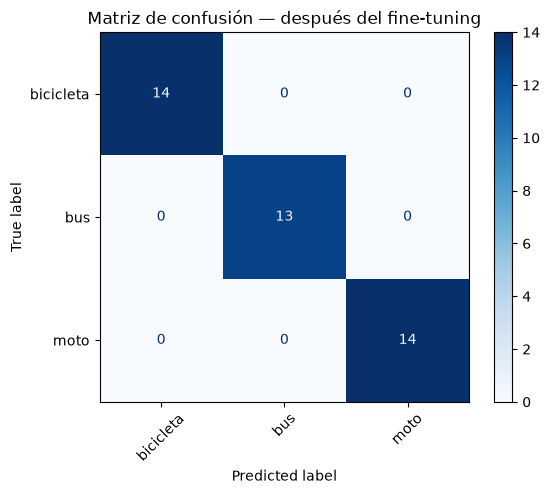

In [23]:
y_true_ft, y_pred_ft, probabilities_ft = get_predictions(model, test_ds)
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names, digits=3))
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — después del fine-tuning")
plt.show()

# 10. Analiza los errores — EN CASA

Una métrica no explica por qué falla un modelo. Debes inspeccionar ejemplos clasificados incorrectamente.

In [24]:
def show_mistakes(dataset, model, class_names, max_images=12):
    mistakes = []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = probs.argmax(axis=1)
        for image, true_label, pred_label, prob in zip(images.numpy(), labels.numpy(), preds, probs):
            if true_label != pred_label:
                mistakes.append((image.astype("uint8"), int(true_label), int(pred_label), float(prob[pred_label])))
    random.shuffle(mistakes)
    mistakes = mistakes[:max_images]
    if not mistakes:
        print("No se encontraron errores en este conjunto.")
        return
    cols = 4
    rows = int(np.ceil(len(mistakes)/cols))
    plt.figure(figsize=(16, 4*rows))
    for i, (image, true_label, pred_label, confidence) in enumerate(mistakes):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(image)
        ax.set_title(f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})")
        ax.axis("off")
    plt.tight_layout()

show_mistakes(test_ds, model, class_names)

No se encontraron errores en este conjunto.


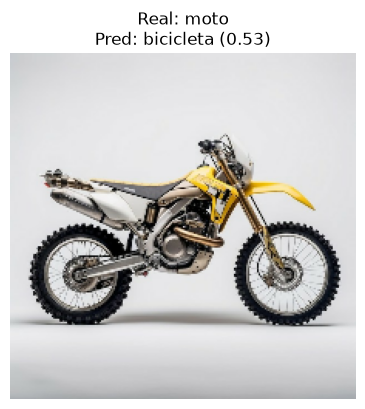

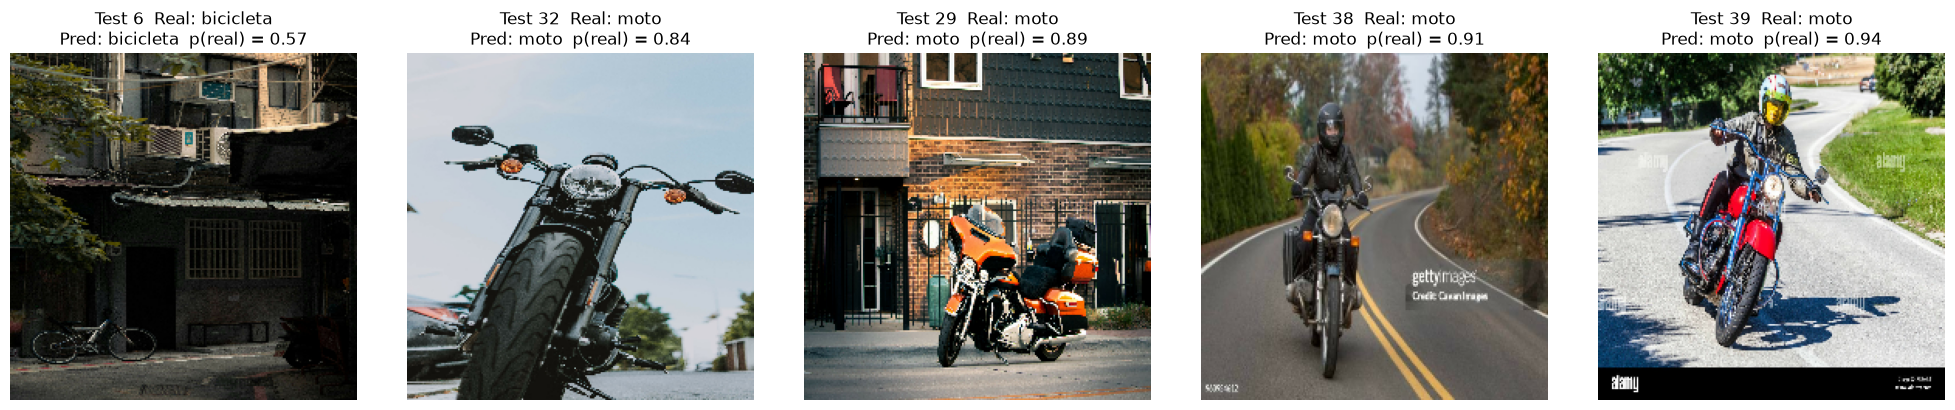

6 bicicleta [0.568 0.236 0.197]
32 moto [0.151 0.013 0.836]
29 moto [0.078 0.032 0.89 ]
38 moto [0.085 0.007 0.908]
39 moto [0.049 0.007 0.945]


In [25]:
# En test no hubo errores, entonces reviso los errores de validation
show_mistakes(val_ds, model, class_names)

# y los casos de test donde el modelo estuvo menos seguro
imagenes_test = np.concatenate([x.numpy() for x, _ in test_ds])
conf_real = probabilities_ft[np.arange(len(y_true_ft)), y_true_ft]
menos_seguros = np.argsort(conf_real)[:5]

plt.figure(figsize=(20, 4))
for k, idx in enumerate(menos_seguros):
    ax = plt.subplot(1, 5, k + 1)
    ax.imshow(imagenes_test[idx].astype("uint8"))
    ax.set_title(f"Test {idx}  Real: {class_names[y_true_ft[idx]]}\nPred: {class_names[y_pred_ft[idx]]}  p(real) = {conf_real[idx]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

for idx in menos_seguros:
    print(idx, class_names[y_true_ft[idx]], np.round(probabilities_ft[idx], 3))

## TODO 6 — EN CASA: análisis de errores y conclusiones

Selecciona al menos **5 errores** del modelo y analiza su causa probable.

| Imagen/error | Clase real | Predicción | Causa probable | ¿Cómo lo mejorarías? |
|---|---|---|---|---|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |

Posibles causas: imagen ambigua, etiqueta incorrecta, objeto pequeño, oclusión, fondo engañoso, clase visualmente similar, mala calidad, sesgo del dataset o error razonable del modelo.

Después, escribe una conclusión breve respondiendo:

1. ¿Qué aprendiste al construir el dataset?
2. ¿Cuál fue el principal problema de calidad?
3. ¿Cuánto cambió el desempeño después del fine-tuning?
4. ¿El fine-tuning ayudó? ¿Por qué crees que sí o no?
5. ¿Qué mejorarías primero: datos, entrenamiento o arquitectura?

**Respuesta:**

En el conjunto de test el modelo no cometió ningún error (41 de 41 bien, antes y después del fine tuning), así que la función `show_mistakes` no mostró nada. Para poder hacer el análisis revisé el único error que hubo en validation y los casos de test donde el modelo estuvo menos seguro de la clase correcta:

| Imagen/error | Clase real | Predicción | Causa probable | ¿Cómo lo mejorarías? |
|---|---|---|---|---|
| 1 (validation) | moto | bicicleta (0.53) | Es una moto de motocross amarilla sobre fondo blanco. Tiene llantas delgadas con rayos y un cuerpo flaco, parecido a una bicicleta de montaña, y casi no hay motocross en el dataset | Agregar búsquedas de "dirt bike" o motocross para que la clase moto tenga más variedad |
| 2 (test 6) | bicicleta | bicicleta (0.57) | Acertó pero con poca confianza. La bicicleta es muy pequeña y oscura en una esquina de la foto, el resto es una calle con edificios | Recortar o quitar fotos donde el objeto ocupa muy poco de la imagen, o buscar más fotos donde la bicicleta sea el centro |
| 3 (test 32) | moto | moto (0.84) | Foto desde abajo de la llanta delantera, ángulo raro que casi no aparece en train | Incluir más ángulos distintos con augmentation (rotaciones más fuertes) o más fotos |
| 4 (test 29) | moto | moto (0.89) | Moto touring naranja estacionada frente a una casa con rejas, el fondo con muchas líneas verticales puede parecerse a los bici parqueaderos | Más fotos de motos estacionadas en la calle para que no asocie el fondo urbano con bicicletas |
| 5 (test 38) | moto | moto (0.91) | Motociclista de frente; desde ese ángulo la moto se ve delgada como una bicicleta y además tiene marca de agua de gettyimages | Quitar imágenes con marca de agua y agregar más fotos frontales de las tres clases |

**Conclusión:**

1. Construir el dataset fue lo que más trabajo dio. Aprendí que lo que devuelve el buscador no es confiable: venían dibujos, infografías, renders, interiores de buses, tranvías, collages y hasta una foto de un faro de moto en la carpeta de bicicletas. Además los términos de búsqueda definen mucho el sesgo, por ejemplo "double decker bus" trajo casi puros buses rojos de Londres.
2. El principal problema de calidad fueron las imágenes que no son fotos reales (ilustraciones, renders y mockups), sobre todo en la clase bus, donde borré 14 de 92. En total borré 27 imágenes: 4 de bicicleta, 14 de bus y 9 de moto. También hay muchas imágenes con marca de agua de bancos de fotos.
3. En test no cambió nada: 1.000 antes y 1.000 después del fine tuning. En validation la accuracy se mantuvo en 0.973 y lo que sí mejoró fue la val_loss, que bajó de 0.1066 a 0.0741.
4. Ayudó un poco, porque el modelo quedó más seguro de sus predicciones (menor loss), pero no se nota en accuracy porque el modelo con la base congelada ya era casi perfecto. Bicicleta, bus y moto son clases que ImageNet ya conoce muy bien (tiene clases de bicicletas, buses y motos), entonces las features preentrenadas ya las separan casi solas.
5. Mejoraría primero los datos: más imágenes por clase (quedaron entre 78 y 89), más variedad (motocross, scooters, buses de otros colores) y un test más grande, porque con 41 imágenes una sola falla cambia la accuracy en 2.4 puntos y un 100 % puede ser en parte suerte.

# Extensión opcional — Prueba con una imagen externa

Busca una imagen que **no esté en tu dataset** y prueba el modelo. Esta parte no cuenta como un TODO principal, pero sirve como comprobación cualitativa de generalización.

In [26]:
# OPCIONAL
# EXTERNAL_IMAGE_URL = "https://..."
# response = requests.get(EXTERNAL_IMAGE_URL, timeout=10)
# response.raise_for_status()
# img = Image.open(io.BytesIO(response.content)).convert("RGB")
# img_resized = img.resize(IMG_SIZE)
# x = np.array(img_resized, dtype="float32")[None, ...]
# p = model.predict(x, verbose=0)[0]
# plt.imshow(img)
# plt.axis("off")
# plt.title(f"{class_names[p.argmax()]} — confianza {p.max():.2f}")
# plt.show()

# 🏠 Cierre conceptual — ENTREGA

Como parte del **TODO 6**, explica con tus propias palabras la diferencia entre:

- **feature extraction / transfer learning con base congelada**;
- **fine-tuning**;
- **entrenar una CNN desde cero**.

No describas solo el código. Explica **qué parámetros se están aprendiendo y de dónde viene el conocimiento inicial**.

**Respuesta:**

**Feature extraction (base congelada):** los pesos de EfficientNet no cambian, vienen de entrenarla con más de un millón de imágenes de ImageNet. La red se usa como un extractor de características que convierte cada foto en un vector de 1280 números, y solo se aprenden los parámetros de la cabeza nueva (la capa Dense de 3 salidas, 3,843 parámetros). Es rápido y funciona con pocas imágenes, como en nuestro caso.

**Fine tuning:** se parte del mismo conocimiento de ImageNet y de la cabeza ya entrenada, pero se dejan entrenar algunas capas finales de la base (aquí 15 de 238, porque las de BatchNormalization siguieron congeladas) con un learning rate muy pequeño (0.00001). Así las características de alto nivel se ajustan un poco a bicicletas, buses y motos sin dañar lo que ya sabía la red.

**Entrenar una CNN desde cero:** todos los pesos empiezan aleatorios y la red tiene que aprender desde los bordes y texturas hasta las formas completas usando solo nuestras imágenes. Con 176 imágenes de entrenamiento eso no funcionaría bien porque son millones de parámetros sin ningún conocimiento previo y se sobreajustaría muy rápido.

# Reto opcional

Elige **uno**:

**A. Más datos:** duplica el número de imágenes manteniendo el modelo igual.  
**B. Otro backbone:** prueba MobileNetV3, ResNet50 o EfficientNetV2B0.  
**C. Dataset difícil:** agrega una cuarta clase visualmente parecida.  
**D. Ablation:** entrena sin `data_augmentation` y compara.

Cambia **una sola variable a la vez**.

Epoch 1/10


C:\Users\Usuario\anaconda3\envs\ia\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


6/6 - 10s - 2s/step - accuracy: 0.4659 - loss: 1.0270 - val_accuracy: 0.8649 - val_loss: 0.6606


Epoch 2/10


6/6 - 2s - 278ms/step - accuracy: 0.9034 - loss: 0.5597 - val_accuracy: 0.9459 - val_loss: 0.3907


...

Epoch 9/10


6/6 - 2s - 275ms/step - accuracy: 1.0000 - loss: 0.0685 - val_accuracy: 0.9730 - val_loss: 0.0905


Epoch 10/10


6/6 - 2s - 275ms/step - accuracy: 1.0000 - loss: 0.0638 - val_accuracy: 1.0000 - val_loss: 0.0823



Con augmentation (fase congelada): mejor val_loss = 0.1066, val_accuracy en esa epoch = 0.9730
Sin augmentation                 : mejor val_loss = 0.0823, val_accuracy en esa epoch = 1.0000


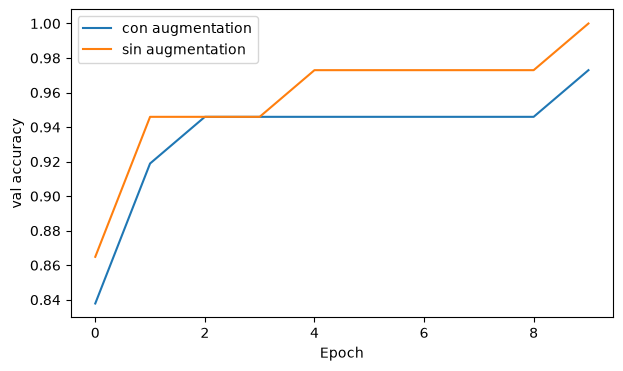

In [27]:
# Reto D: mismo modelo pero sin data augmentation, solo la fase con la base congelada
keras.utils.set_random_seed(SEED)

base_sin_aug = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_sin_aug.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_sin_aug(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_sin_aug = keras.Model(inputs, outputs)

model_sin_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_sin_aug = model_sin_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=2,
)

print()
print("Con augmentation (fase congelada): mejor val_loss = %.4f, val_accuracy en esa epoch = %.4f" % (
    min(history.history["val_loss"]), history.history["val_accuracy"][int(np.argmin(history.history["val_loss"]))]))
print("Sin augmentation                 : mejor val_loss = %.4f, val_accuracy en esa epoch = %.4f" % (
    min(history_sin_aug.history["val_loss"]), history_sin_aug.history["val_accuracy"][int(np.argmin(history_sin_aug.history["val_loss"]))]))

plt.figure(figsize=(7, 4))
plt.plot(history.history["val_accuracy"], label="con augmentation")
plt.plot(history_sin_aug.history["val_accuracy"], label="sin augmentation")
plt.xlabel("Epoch")
plt.ylabel("val accuracy")
plt.legend()
plt.show()

**Escogí la opción D (ablation sin data augmentation).** El resultado no fue el que esperaba: sin augmentation la fase congelada llegó a val_loss de 0.0823 y val_accuracy de 1.0 en la epoch 10, mientras que con augmentation el mejor val_loss fue 0.1066 con val_accuracy de 0.973. O sea que en este dataset quitar el augmentation no empeoró nada, incluso aprendió un poco más rápido. Creo que pasa porque las tres clases son muy fáciles de separar con las features de ImageNet, entonces el augmentation solo hace el entrenamiento un poco más difícil y en 10 epochs no alcanza a mostrar su ventaja. Igual la validación tiene solo 37 imágenes, así que una diferencia de una imagen no es suficiente para decir que el augmentation no sirve; con datos más difíciles o más epochs seguramente ayudaría a generalizar.

# ✅ Checklist de entrega

Antes de entregar verifica:

### Evidencia del trabajo en clase
- [x] Problema y clases definidos.
- [x] Dataset construido y revisado.
- [x] Train / validation / test creados.
- [x] Primer modelo con backbone congelado entrenado.

### Trabajo en casa
- [x] Evaluación sobre test.
- [x] Matriz de confusión.
- [x] Precision / recall / F1 interpretados.
- [x] Fine-tuning ejecutado.
- [x] Comparación antes vs. después del fine-tuning.
- [x] Al menos 5 errores analizados.
- [x] Conclusión final escrita.

### Opcional
- [ ] Imagen externa.
- [x] Experimento adicional / reto.

# Rúbrica sugerida

| Componente | Peso |
|---|---:|
| TODO 1 — Problema y estrategia de búsqueda | 10% |
| TODO 2 — Construcción, inspección y limpieza del dataset | 20% |
| Split y pipeline de datos | 10% |
| TODO 3 — Transfer learning + curvas | 20% |
| TODO 4 — Evaluación e interpretación | 10% |
| TODO 5 — Fine-tuning y comparación | 15% |
| TODO 6 — Análisis de errores + conclusión conceptual | 15% |
| **Total** | **100%** |